In [5]:
import numpy as np

# Crear el vector de productos
productos = np.array([1]*10 + [2]*5 + [3]*5 + [0]*80)

# Revolver los productos (muestreo sin reemplazo)
productos_revueltos = np.random.choice(productos, size=100, replace=False)
print("Productos revueltos:")
print(productos_revueltos)

# Definir eventos
evento_A = np.array([1, 3])
evento_B = np.array([2, 3])
evento_AyB = np.array([3])

# Tomar una muestra de tamaño 90 sin reemplazo
tamaño = 90
muestra = np.random.choice(productos_revueltos, size=tamaño, replace=False)


Productos revueltos:
[0 0 0 0 0 3 1 0 0 1 0 0 1 0 2 0 0 0 0 0 1 0 2 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 3 0 0 0 0 0 0 0 1 2 0 0 0 3 0 0 2 0 3 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 0 1 0 2]


In [6]:
# Probabilidad de tener algún defecto (A ∪ B)
# P(A ∪ B) = P(A) + P(B) - P(A ∩ B)
(np.isin(muestra, evento_A).sum() +
                np.isin(muestra, evento_B).sum() -
                np.isin(muestra, evento_AyB).sum()) / tamaño

np.float64(0.17777777777777778)

In [7]:
# Probabilidad de tener únicamente defecto estético (A \ B)
(np.isin(muestra, evento_A).sum() - np.isin(muestra, evento_AyB).sum()) / tamaño


np.float64(0.1)

In [17]:
####################################################### simulacion para varios tamaños

import pandas as pd

def simulacion(tamaño):
  muestra = np.random.choice(productos_revueltos,size=tamaño,replace=False)
  return (np.sum(np.isin(muestra,evento_A))+np.sum(np.isin(muestra,evento_B))-np.sum(np.isin(muestra,evento_AyB)))/tamaño


In [24]:
resultados = [simulacion(x) for x in range(1,101)]
simulaciones = pd.DataFrame({"tamaño":range(1,101),"probabilidad":resultados})

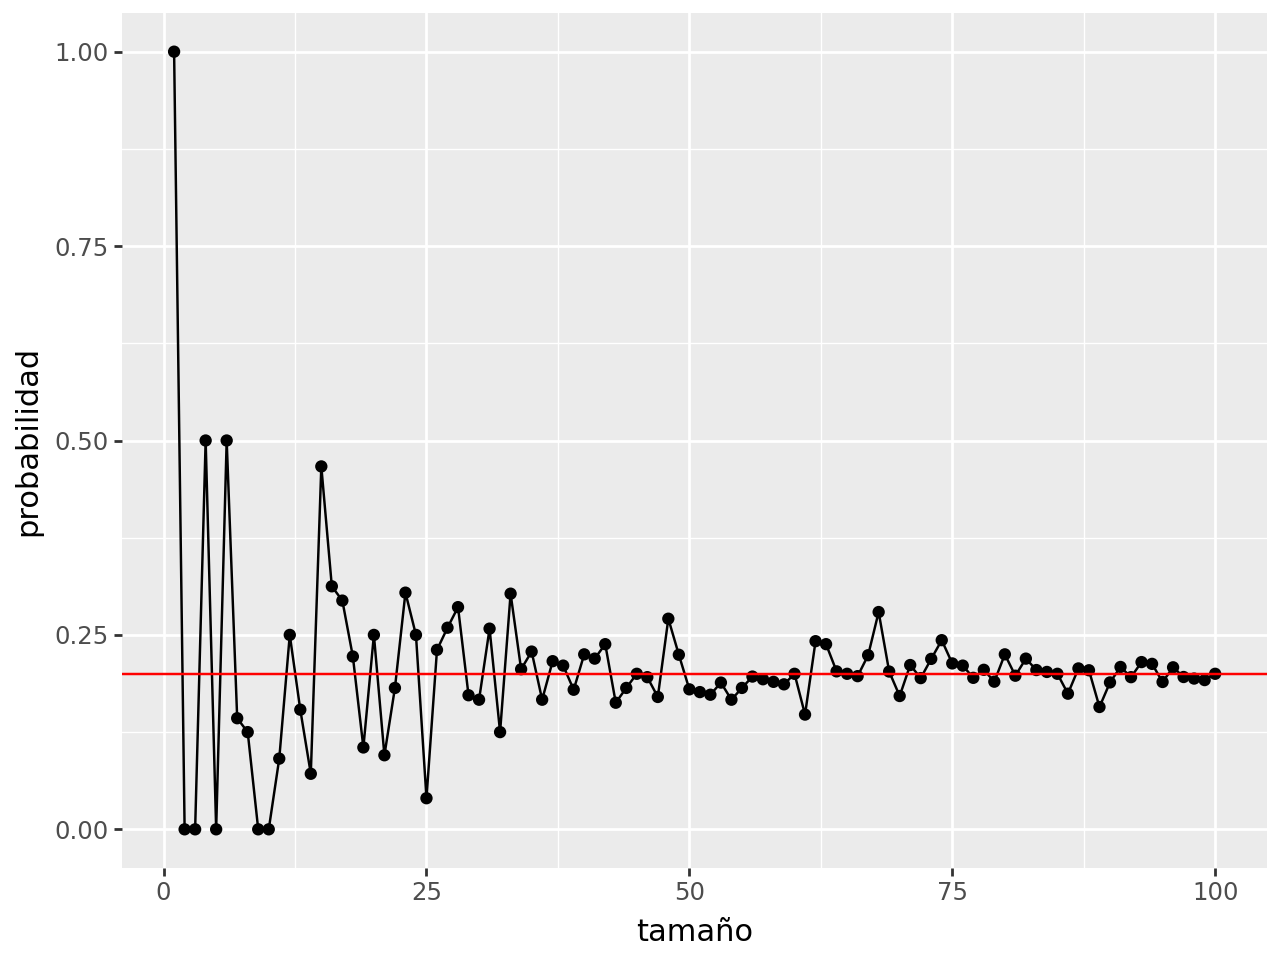

In [26]:
from plotnine import *

(
ggplot(data = simulaciones) +
  geom_point(mapping=aes(x="tamaño",y="probabilidad")) +
  geom_line(mapping=aes(x="tamaño",y="probabilidad")) +
  geom_hline(yintercept=0.2,color="red")
)